# Deep Learning model — 7-day weather forecast

A **seq2seq (encoder-decoder + attention)** neural network with a station **embedding** that predicts **tmax, tmin and precipitation for the next 7 days** from the **last 30 days** of observations, for any station in the AEMET network.

It is a **single global model**: the embedding learns a per-station vector that captures its climate (latitude, altitude, continentality), instead of training one model per station.

> Results computed with database data up to **2026-04-27** (fixed snapshot).

## 1. Data and station selection

- **Input**: 30 days of 13 meteorological variables + 2 cyclical day-of-year features (`doy_sin`, `doy_cos`) + station code.
- **Output**: 7 days of `tmax`, `tmin`, `prec` → tensor `(7, 3)`.
- **History**: 15 years (justified empirically below).

**Note on stations**: the EDA criterion (date coverage, ~98 WMO stations) is **not** the one that trains the model. The pipeline discards any 37-day window with a NaN in its features (`sol`, pressure and humidity have 25-48% gaps) and keeps only stations with ≥1000 valid windows → **~137 usable stations**.

## 2. Architecture

**Encoder-decoder with attention** (Luong dot-product), non-autoregressive:

- **Station embedding** (dim 16) → concatenated to the input sequence to condition the dynamics from the first step.
- **Encoder**: LSTM(64) that reads the 30 days and returns one state per day.
- **Decoder**: LSTM(64) that generates the 7 forecast days.
- **Attention**: each predicted day weighs which input days to look at (key at long horizons).
- Regularization: dropout 0.35, learning rate 5e-4 (tuned against overfitting).

A stacked baseline LSTM was also tested: it performs **the same** as seq2seq within seed noise. seq2seq is kept as the standard architecture for multi-horizon forecasting.

---
*Attention mechanism: Luong, M.-T., Pham, H., & Manning, C. D. (2015). Effective Approaches to Attention-based Neural Machine Translation. arXiv:1508.04025.*

## 3. Evaluation methodology

Evaluating on a single 7-day window is misleading. We use **rolling-origin** over the holdout region (~12 real out-of-sample origins) and report the **skill score**:

$$ SS = 1 - \frac{MAE_{model}}{MAE_{baseline}} $$

against **two** baselines: **persistence** ("tomorrow = today") and **climatology** (historical mean for that date and station). Beating climatology is the hard bar. Rain is scored with POD/FAR/CSI.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Results as a fixed snapshot: database up to 2026-04-27, rolling-origin holdout (12 origins, 30 stations).
DATA_CUTOFF = "2026-04-27"
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 9,
})

## 4. How many years of history help? (the "inverted U")

Sweep of `YEARS_HISTORY` with evaluation fixed on the recent block and fixed climatology/stations (a reverse expanding window). Skill **rises up to 15-20 years and drops at 30**: older data reflects a slightly different climate (drift) and has more gaps. → **15 years** is the best skill/data trade-off.

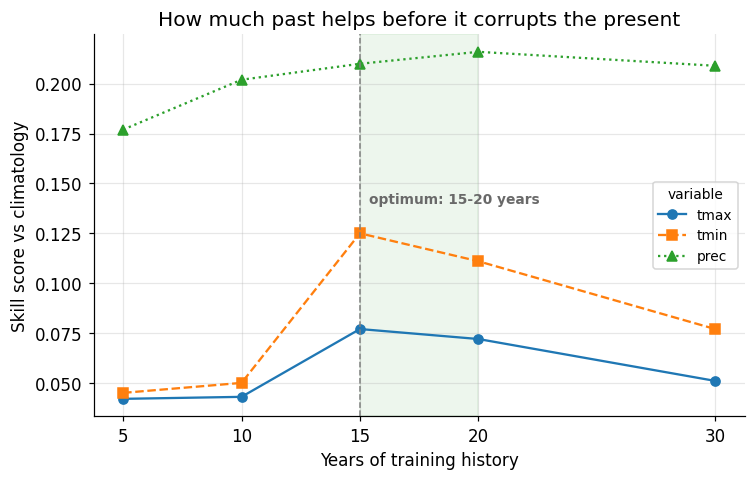

In [2]:
years = [5, 10, 15, 20, 30]
skill_clim = {
    "tmax": [0.042, 0.043, 0.077, 0.072, 0.051],
    "tmin": [0.045, 0.050, 0.125, 0.111, 0.077],
    "prec": [0.177, 0.202, 0.210, 0.216, 0.209],
}
# distinct marker + line style per variable (readable in grayscale / for color-blind readers)
styles = {"tmax": ("o", "-"), "tmin": ("s", "--"), "prec": ("^", ":")}

fig, ax = plt.subplots(figsize=(7, 4.5))
for var, ys in skill_clim.items():
    mk, ls = styles[var]
    ax.plot(years, ys, marker=mk, linestyle=ls, label=var)
ax.axvspan(15, 20, color="green", alpha=0.07)
ax.axvline(15, color="grey", ls="--", lw=1)
ax.annotate("optimum: 15-20 years", xy=(15.4, 0.140), fontsize=9, color="dimgrey", fontweight="bold")
ax.set_xlabel("Years of training history")
ax.set_ylabel("Skill score vs climatology")
ax.set_title("How much past helps before it corrupts the present")
ax.set_xticks(years)
ax.legend(title="variable", fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.savefig("figures/inverted_u.png", bbox_inches="tight")
plt.show()

## 5. Final results per variable

The model **beats persistence on all 3 variables** and **climatology on tmin and precipitation**. `tmax` stays level with climatology: this is the **predictability ceiling** of a model based only on station history (without numerical weather prediction data).

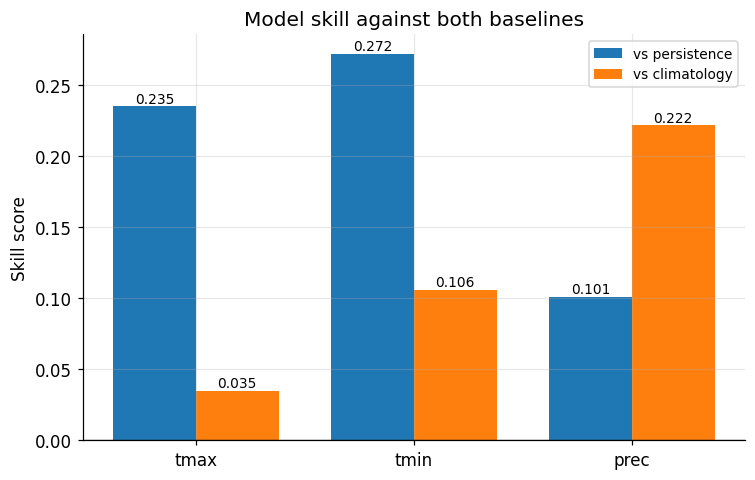

In [3]:
variables = ["tmax", "tmin", "prec"]
vs_persist = [0.235, 0.272, 0.101]
vs_clim = [0.035, 0.106, 0.222]

x = np.arange(len(variables)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w/2, vs_persist, w, label="vs persistence", color="#1f77b4")
b2 = ax.bar(x + w/2, vs_clim, w, label="vs climatology", color="#ff7f0e")
ax.bar_label(b1, fmt="%.3f", fontsize=9); ax.bar_label(b2, fmt="%.3f", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(variables)
ax.set_ylabel("Skill score")
ax.set_title("Model skill against both baselines")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/skill_by_variable.png", bbox_inches="tight")
plt.show()

## 6. Degradation by horizon

MAE (°C / mm) per forecast day. **Persistence collapses** as the horizon grows, while the model degrades smoothly: it only "loses" to persistence at day +1 of temperature (where "tomorrow ≈ today" is very hard to beat).

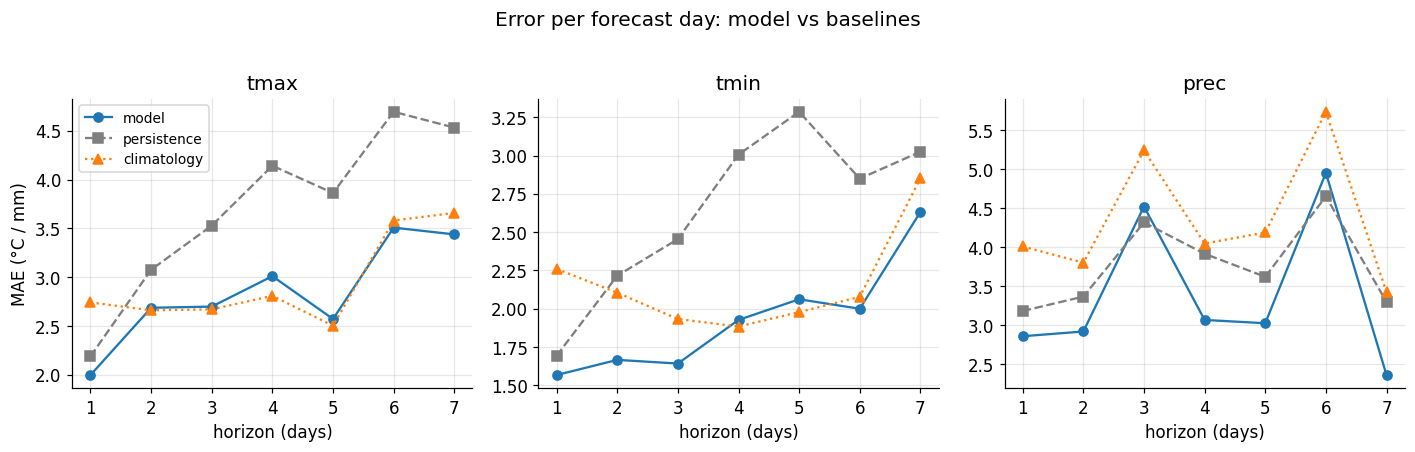

In [4]:
h = np.arange(1, 8)
mae = {
    "tmax": {"model": [1.998, 2.687, 2.699, 3.011, 2.572, 3.508, 3.439],
             "persistence": [2.190, 3.077, 3.529, 4.142, 3.863, 4.695, 4.533],
             "climatology": [2.742, 2.661, 2.671, 2.809, 2.504, 3.581, 3.659]},
    "tmin": {"model": [1.566, 1.665, 1.641, 1.926, 2.061, 1.999, 2.631],
             "persistence": [1.692, 2.215, 2.454, 3.006, 3.286, 2.849, 3.025],
             "climatology": [2.259, 2.104, 1.932, 1.883, 1.977, 2.077, 2.851]},
    "prec": {"model": [2.855, 2.916, 4.520, 3.064, 3.022, 4.952, 2.357],
             "persistence": [3.179, 3.364, 4.315, 3.913, 3.618, 4.650, 3.294],
             "climatology": [4.007, 3.799, 5.240, 4.045, 4.187, 5.736, 3.421]},
}
# each series has its own marker + line style (readable without color)
series_style = {"model": ("-o", "#1f77b4"), "persistence": ("--s", "#7f7f7f"), "climatology": (":^", "#ff7f0e")}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, var in zip(axes, variables):
    for name, (fmt, color) in series_style.items():
        ax.plot(h, mae[var][name], fmt, label=name, color=color)
    ax.set_title(var); ax.set_xlabel("horizon (days)")
axes[0].set_ylabel("MAE (°C / mm)")
axes[0].legend(fontsize=9)
fig.suptitle("Error per forecast day: model vs baselines", y=1.02)
plt.tight_layout()
plt.savefig("figures/mae_by_horizon.png", bbox_inches="tight")
plt.show()

## 7. Rain detection (≥ 1 mm)

Event metrics for precipitation:
- **POD** (detection, ↑ better): fraction of rainy days the model catches.
- **FAR** (false alarm ratio, ↓ better): fraction of rain warnings that don't verify.
- **CSI** (critical success index, ↑ better): combines both; the summary metric.

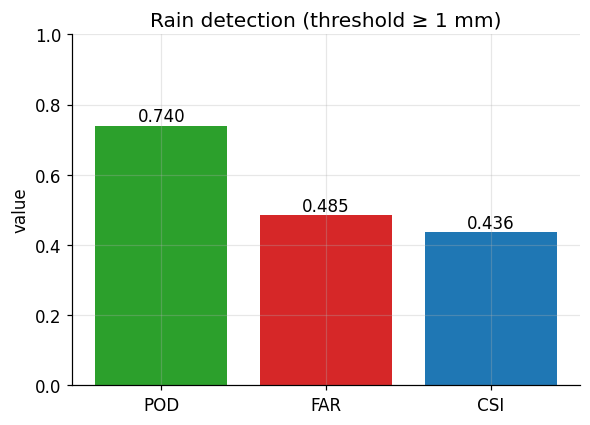

In [5]:
rain_metrics = ["POD", "FAR", "CSI"]
rain_vals = [0.740, 0.485, 0.436]
rain_colors = ["#2ca02c", "#d62728", "#1f77b4"]

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(rain_metrics, rain_vals, color=rain_colors)
ax.bar_label(bars, fmt="%.3f")
ax.set_ylim(0, 1)
ax.set_ylabel("value")
ax.set_title("Rain detection (threshold ≥ 1 mm)")
plt.tight_layout()
plt.savefig("figures/rain_pod_far_csi.png", bbox_inches="tight")
plt.show()

## 8. Comparison with the ML baseline (XGBoost / LightGBM)

The tree-based models from notebook `3-ML_baseline` are a **legitimate baseline**, but they cannot use the station embedding and treat the inputs as static lag features. We compare them with the DL model on the **same 4 prototype stations** (Córdoba, Burgos, Navacerrada, Palma).

> **Protocol note (honest)**: the ML baseline was evaluated with expanding-window CV over ~20 years; the DL model on a recent 90-day rolling-origin holdout. The test periods differ, so the *temperature* numbers are **indicative**, not a controlled head-to-head. For *precipitation* the gap is qualitative (skill vs no skill) and robust to this difference.

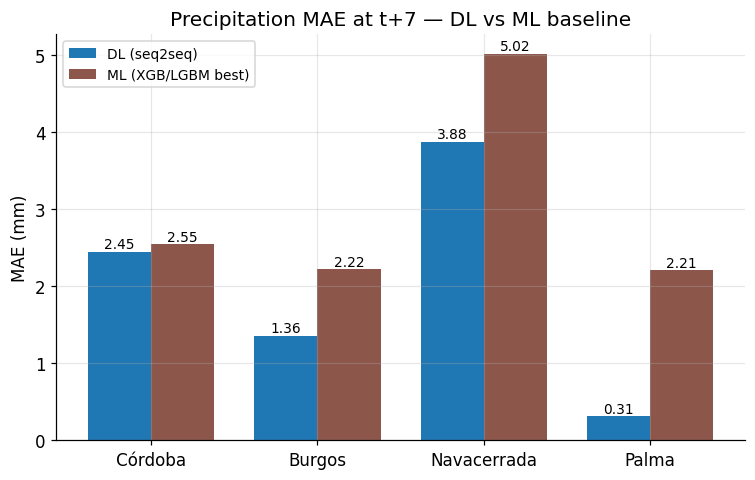

Precipitation MAE (mm) — DL vs ML


t+1         t+3         t+7      
               DL    ML    DL    ML    DL    ML
Córdoba      2.48  2.17  2.86  2.48  2.45  2.55
Burgos       1.12  1.94  1.48  2.21  1.36  2.22
Navacerrada  4.08  4.11  4.15  4.87  3.88  5.02
Palma        0.23  2.03  0.30  2.21  0.31  2.21

In [6]:
stations_names = ["Córdoba", "Burgos", "Navacerrada", "Palma"]

def cmp_table(dl, ml):
    cols = {}
    for hz in ["t+1", "t+3", "t+7"]:
        cols[(hz, "DL")] = dl[hz]; cols[(hz, "ML")] = ml[hz]
    return pd.DataFrame(cols, index=stations_names)

# --- Precipitation MAE (mm) ---
dl_prec = {"t+1": [2.48, 1.12, 4.08, 0.23], "t+3": [2.86, 1.48, 4.15, 0.30], "t+7": [2.45, 1.36, 3.88, 0.31]}
ml_prec = {"t+1": [2.17, 1.94, 4.11, 2.03], "t+3": [2.48, 2.21, 4.87, 2.21], "t+7": [2.55, 2.22, 5.02, 2.21]}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(stations_names)); w = 0.38
b1 = ax.bar(x - w/2, dl_prec["t+7"], w, label="DL (seq2seq)", color="#1f77b4")
b2 = ax.bar(x + w/2, ml_prec["t+7"], w, label="ML (XGB/LGBM best)", color="#8c564b")
ax.bar_label(b1, fmt="%.2f", fontsize=9); ax.bar_label(b2, fmt="%.2f", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(stations_names)
ax.set_ylabel("MAE (mm)")
ax.set_title("Precipitation MAE at t+7 — DL vs ML baseline")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/precip_dl_vs_ml.png", bbox_inches="tight")
plt.show()

print("Precipitation MAE (mm) — DL vs ML")
cmp_table(dl_prec, ml_prec)

**Precipitation — the clear win.** The ML baseline has **essentially no skill** (R² ≈ 0 at t+1, collapsing to ~0 at t+7). The DL model keeps a **positive skill vs climatology at every horizon and station** (+0.27 to +0.77 at t+1, still +0.27 to +0.69 at t+7) and a lower or comparable MAE at 3 of the 4 stations — dramatically lower at Palma. This is exactly where a sequence model that captures temporal dynamics helps and where tree models with static features cannot.

In [7]:
# --- Temperature MAE (°C) ---
dl_tmax = {"t+1": [1.89, 2.62, 2.49, 1.23], "t+3": [2.36, 3.81, 4.23, 1.29], "t+7": [2.90, 3.87, 4.29, 1.71]}
ml_tmax = {"t+1": [1.65, 2.21, 1.92, 1.37], "t+3": [2.65, 3.31, 3.45, 1.73], "t+7": [2.94, 3.58, 3.97, 1.89]}
dl_tmin = {"t+1": [1.90, 1.61, 1.80, 0.42], "t+3": [2.31, 2.08, 3.11, 0.78], "t+7": [2.47, 2.26, 3.02, 1.53]}
ml_tmin = {"t+1": [1.44, 1.70, 1.47, 1.07], "t+3": [2.10, 2.48, 2.77, 1.52], "t+7": [2.32, 2.64, 3.14, 1.69]}

print("tmax MAE (°C) — DL vs ML"); display(cmp_table(dl_tmax, ml_tmax))
print("tmin MAE (°C) — DL vs ML"); cmp_table(dl_tmin, ml_tmin)

tmax MAE (°C) — DL vs ML


t+1         t+3         t+7      
               DL    ML    DL    ML    DL    ML
Córdoba      1.89  1.65  2.36  2.65  2.90  2.94
Burgos       2.62  2.21  3.81  3.31  3.87  3.58
Navacerrada  2.49  1.92  4.23  3.45  4.29  3.97
Palma        1.23  1.37  1.29  1.73  1.71  1.89

tmin MAE (°C) — DL vs ML


t+1         t+3         t+7      
               DL    ML    DL    ML    DL    ML
Córdoba      1.90  1.44  2.31  2.10  2.47  2.32
Burgos       1.61  1.70  2.08  2.48  2.26  2.64
Navacerrada  1.80  1.47  3.11  2.77  3.02  3.14
Palma        0.42  1.07  0.78  1.52  1.53  1.69

**Temperature — comparable, both strong.** Gradient boosting is a strong temperature baseline (temperature is highly autocorrelated, so lag features work well): it edges the DL model at t+1 on the continental stations, while the DL model is better at Palma and at some longer horizons. Given the differing test periods we do **not** claim a clear DL win here — the honest read is *comparable*.

## 9. Conclusions and limitations

**Conclusions**
- A single global model with a station embedding beats persistence on all 3 variables and climatology on tmin and precipitation.
- Attention helps mostly at long horizons (day +7).
- 15 years of history is the empirical optimum (the "inverted U").
- vs the ML baseline: **comparable on temperature**, but the DL model **adds real precipitation skill** where gradient boosting has none.

**Known limitations (honest)**
- **`tmax` ceiling**: level with climatology. A model based only on station history has a limit against numerical weather prediction (NWP), which solves the atmospheric physics.
- **Precipitation**: already beats climatology (+0.22), but it is intrinsically the hardest variable (zero-inflated). Improving it further would require a *hurdle* model (rain/no-rain classification + amount regression).
- **Non-stationarity**: climate change introduces a drift the model does not explicitly handle.

**Future work**: exogenous data (NWP, neighboring stations), probabilistic output (quantiles/CRPS), hurdle model for precipitation.